AllenNLP not available. Registrable won't work.


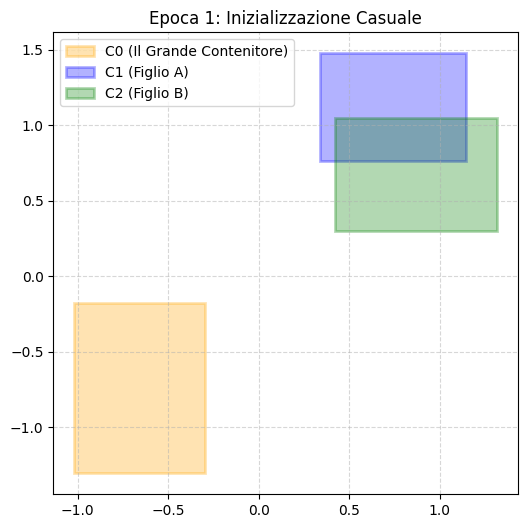

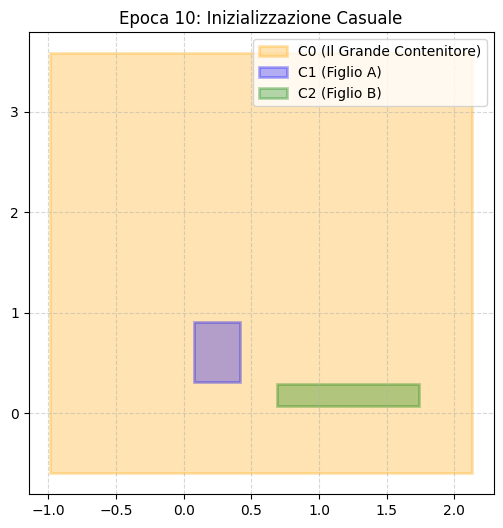

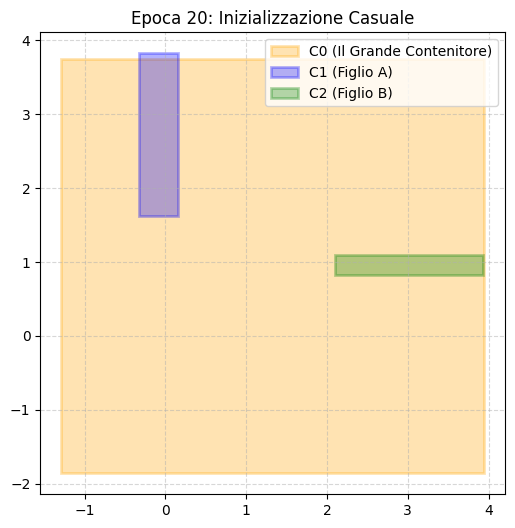

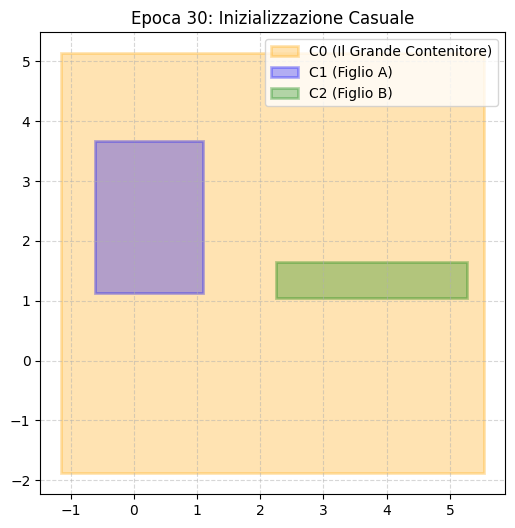

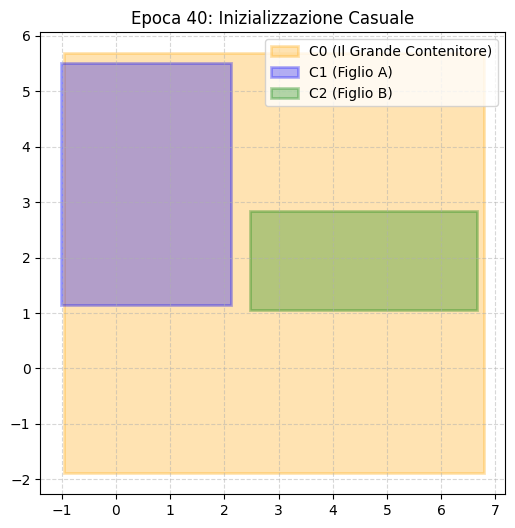

Epoca 40/50 | Loss Totale: -0.8174


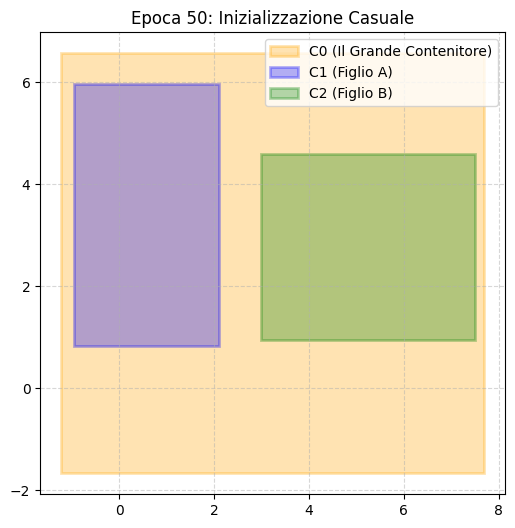

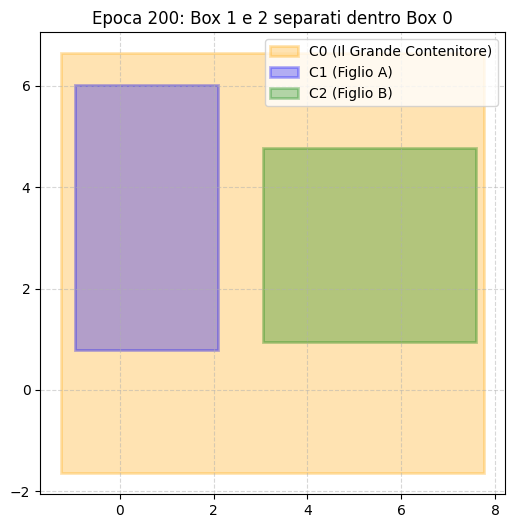

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from box_embeddings.parameterizations import MinDeltaBoxTensor
from box_embeddings.modules.intersection import GumbelIntersection
from box_embeddings.modules.volume import SoftVolume
from box_embeddings.modules.regularization import L2SideBoxRegularizer
from box_embeddings.modules.volume import BesselApproxVolume

# --- 1. SETUP ---
num_concepts = 3  # Ora abbiamo 3 concetti!
num_dims = 2
feature_dim = 64

torch.manual_seed(42)
features = torch.randn(feature_dim)
# Creiamo una lista di 3 layer separati. 
# Ognuno proietta le 64 feature nei 4 valori necessari per un singolo box (2 coordinate x 2 dimensioni)
projectors = nn.ModuleList([
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims), # Proiettore Concetto 0
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims), # Proiettore Concetto 1
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims)  # Proiettore Concetto 2
])

# Passiamo i parametri di TUTTA la ModuleList all'ottimizzatore
optimizer = torch.optim.Adam(projectors.parameters(), lr=0.01)

gumbel_intersection = GumbelIntersection(intersection_temperature=0.1)
#bessel_volume = BesselApproxVolume(volume_temperature=10.0, intersection_temperature=0.8)
soft_volume = SoftVolume(volume_temperature=0.5)

# --- 2. LA NOSTRA GROUND TRUTH ---
# Formato: (id_contenitore_desiderato, id_box_di_riferimento, probabilità_target)
# Questo modella: P(id_contenitore | id_riferimento) = target
supervisions = [
    (0, 1, 1.0),  # Box 0 deve contenere Box 1
    (0, 2, 1.0),  # Box 0 deve contenere Box 2
    (1, 2, 0.0),  # Box 1 deve essere disgiunto dal Box 2
    (2, 1, 0.0),  # Box 2 deve essere disgiunto dal Box 1
]

# Aggiungiamo un peso piccolo per non sovrastare la Cross Entropy
#box_regularizer = L2SideBoxRegularizer(log_scale=True, weight=0.01)

# --- 3. FUNZIONE DI VISUALIZZAZIONE AGGIORNATA ---
def plot_boxes(boxes_tensor, title="Box Embeddings"):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ['orange', 'blue', 'green']
    labels = ['C0 (Il Grande Contenitore)', 'C1 (Figlio A)', 'C2 (Figlio B)']
    
    z_coords = boxes_tensor.z.detach().numpy()
    Z_coords = boxes_tensor.Z.detach().numpy()
    
    for i in range(num_concepts):
        width = Z_coords[i, 0] - z_coords[i, 0]
        height = Z_coords[i, 1] - z_coords[i, 1]
        
        rect = patches.Rectangle((z_coords[i, 0], z_coords[i, 1]), width, height, 
                                 linewidth=2, edgecolor=colors[i], facecolor=colors[i], 
                                 alpha=0.3, label=labels[i])
        ax.add_patch(rect)
        
    ax.autoscale_view()
    plt.legend()
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- 4. LOOP DI ADDESTRAMENTO ---
epochs = 50

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Proiettiamo le feature passando attraverso i tre layer separati
    theta_0 = projectors[0](features) # Shape: (4)
    theta_1 = projectors[1](features) # Shape: (4)
    theta_2 = projectors[2](features) # Shape: (4)
    
    # 2. Impiliamo i risultati in un unico tensore. Shape: (3, 2, 2)
    theta_flat = torch.stack([theta_0, theta_1, theta_2])
    theta_reshaped = theta_flat.view(num_concepts, 2, num_dims)
    concept_boxes = MinDeltaBoxTensor(theta_reshaped)
    
    if epoch == 0 or (epoch + 1) % 10 == 0:
        plot_boxes(concept_boxes, title=f"Epoca {epoch + 1}: Inizializzazione Casuale")
    
    total_loss = 0.0
    
    # Iteriamo su tutte le relazioni della nostra ground truth
    for target_id, source_id, target_prob in supervisions:
        box_target = concept_boxes[target_id]
        box_source = concept_boxes[source_id]
        
        # 1. Calcoliamo l'intersezione
        int_box = gumbel_intersection(box_target, box_source)
        
        # 2. Calcoliamo i volumi (in logaritmo per stabilità)
        log_vol_int = soft_volume(int_box)
        log_vol_source = soft_volume(box_source)
        
        # 3. Trasformiamo in Probabilità: e^(log_int - log_source)
        # Usiamo torch.clamp per evitare che la probabilità esca da [0, 1] a causa delle approssimazioni
        pred_prob = torch.exp(log_vol_int - log_vol_source)
        pred_prob = torch.clamp(pred_prob, 1e-6, 1.0 - 1e-6)
        
        # 4. Calcoliamo la Binary Cross Entropy rispetto al target
        target_tensor = torch.tensor(target_prob, dtype=torch.float32)
        loss = F.binary_cross_entropy(pred_prob, target_tensor)
        
        total_loss += loss
    
    # --- LE NOSTRE CONTROMISURE ANTI-CHEAT ---
    
    # 1. Penalità contro i box lunghi e stretti (spaghetti)
    #reg_loss = box_regularizer(concept_boxes)
    
    # 2. Incoraggiamo C1 e C2 a non collassare a puntini microscopici
    # (Minimizzare il log-volume negativo = spingere i volumi a crescere un po')
    vol_loss = -0.2 * (soft_volume(concept_boxes[1]) + soft_volume(concept_boxes[2]))

    final_loss = total_loss + vol_loss #+ reg_loss

    final_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoca {epoch + 1}/{epochs} | Loss Totale: {final_loss.item():.4f}")

# Visualizziamo il risultato finale

theta_0 = projectors[0](features) # Shape: (4)
theta_1 = projectors[1](features) # Shape: (4)
theta_2 = projectors[2](features) # Shape: (4)
    
# 2. Impiliamo i risultati in un unico tensore. Shape: (3, 2, 2)
theta_flat = torch.stack([theta_0, theta_1, theta_2])
theta_reshaped = theta_flat.view(num_concepts, 2, num_dims)

final_boxes = MinDeltaBoxTensor(theta_reshaped)
plot_boxes(final_boxes, title="Epoca 200: Box 1 e 2 separati dentro Box 0")